# Notes as I go for results of various analyses

## Step 1: Quality control

Labeling was completed primarily by four UCSB undergraduate students: DSB, JL, KL, and MV, with each labeling roughly 600 images. First author Anna Boser labeled 51 images across 25 locations to serve as a quality control dataset, which all other labelers also labeled. Additionally, a native Zambian undergraduate student in the school of Agricultural Sciences at the University of Lusaka, Peter Siame, labeled one 25 location survey for each of the four other labelers to provide additional comparison data.

Here, we display the comparison results generated in labeler comparison. In particular, we compare metrics on (1) overall detection of any irrigation presence/absence at the image level and (2) overlap of the specific areas marked as irrigated.

In [13]:
import pandas as pd

In [10]:
# Read in the quality control outputs with certainty threshold 3

ab_area = pd.read_csv(
    '../outputs/quality_control/ab_comparisons_cert_3/area_overlap_metrics.csv')
ab_detection = pd.read_csv(
    '../outputs/quality_control/ab_comparisons_cert_3/image_detection_metrics.csv')
ps_area = pd.read_csv(

    '../outputs/quality_control/ps_comparisons_cert_3/area_overlap_metrics.csv')
ps_detection = pd.read_csv(
    '../outputs/quality_control/ps_comparisons_cert_3/image_detection_metrics.csv')

### Comparison to Anna Boser's labels

In [28]:
# Image-level detection metrics for comparison to Anna Boser
ab_detection

,Operator,Matched Images,Total Images Labeled,TP,FP,FN,TN,Precision,Recall,F1
0,DSB,47,588,12,0,4,31,1.0,0.750000,0.857143
1,JL,48,582,9,0,8,31,1.0,0.529412,0.692308
2,KL,48,681,12,0,4,32,1.0,0.750000,0.857143
3,MV,50,623,14,0,3,33,1.0,0.823529,0.903226
4,PS,48,204,9,0,7,32,1.0,0.562500,0.720000
5,Weighted Avg,241,2678,56,0,26,159,1.0,0.704883,0.821593


In [29]:
# Average F1 score across 4 primary labelers (weighted by number of images labeled by each labeler)
def weighted_metric(df, metric, labelers=['DSB', 'JL', 'KL', 'MV']):
    four_labelers = df[df['Operator'].isin(labelers)]
    weighted_metric = (four_labelers[metric] * four_labelers['Total Images Labeled']).sum() / four_labelers['Total Images Labeled'].sum()
    return weighted_metric

print(f'Image-level detection F1 Score:', weighted_metric(ab_detection, 'F1'))
print(f'Image-level detection Recall:', weighted_metric(ab_detection, 'Recall'))

Image-level detection F1 Score: 0.8299705093196108
Image-level detection Recall: 0.7166234723477103


Overall, we find a high degree of agreement with Anna Boser's labels at the iage level, with the average F1 score (weighted by the number of images labeled by each labeler) of 0.83 across the four primary labelers. Importantly, the precision for every labeler is 1, indicating that labelers do not generally erroneously find irrigation in images where there is none, though they may miss some, with a recall of 0.72. 

In [30]:
# Area overlap metrics for comparison to Anna Boser
ab_area

,Operator,Total Images Labeled,Precision,Recall,F1,IoU
0,DSB,588,0.586499,0.317768,0.412203,0.259607
1,JL,582,0.593105,0.268318,0.369483,0.226605
2,KL,681,0.750548,0.575316,0.651352,0.482967
3,MV,623,0.930122,0.354760,0.513620,0.345551
4,PS,204,0.782884,0.286984,0.420006,0.265827
5,Weighted Avg,2678,0.724550,0.378775,0.487921,0.329701


In [31]:
print(f'Area overlap F1 Score:', weighted_metric(ab_area, 'F1'))
print(f'Area overlap Precision:', weighted_metric(ab_area, 'Precision'))
print(f'Area overlap Recall:', weighted_metric(ab_area, 'Recall'))
print(f'Area overlap IoU:', weighted_metric(ab_area, 'IoU'))

Area overlap F1 Score: 0.4935208245334865
Area overlap Precision: 0.7197403916324517
Area overlap Recall: 0.3863438315715838
Area overlap IoU: 0.33496821653313363


Precision for area of overlap remains high, at 0.72. The disagreement likely stems from missed irrigation annotations by Anna Boser and an imperfect definition criteria: sometimes it is difficult to determine what is being "actively irrigated". For example, exacty how green should it be? 

Recall is low, at .38, suggesting that annotators do miss irrigated areas, either because they are generally small and hard to spot or again because it can be difficult to decide what is "irrigated enough". 

Overall, the F1 score for area of overlap is 0.49. 

This image demonstrates how it can be easy to miss irrigaed areas as well as feel unsure about how clearly and actively irrigated something must be to be counted as irrigated. 

![GEE_labeling_example.png](GEE_labeling_example.png)

![labels](../outputs/quality_control/ab_comparisons_cert_3/id_5062566_2019-06-14.png)



In general, these results suggest that while regions marked as irrigated in our dataset can be trusted to be irrigated, some areas that may be less obviously active or particularly small and difficult to spot may have been missed. For the purpose of training our dataset, this is likely to cause minimal issues because there is an overwhelming abundance of unirrigated area to train from. 

Uncertainty, especially with false negatives, is a bigger challenge for model testing, however, since a model with poor precision may actually simply be identifying irrigated regions the labeler missed. We therefore elect to exclusively use Karena Lai's labels for the test set, whose precision is high at 0.75 and recall is highest among all labelers at 0.57. We note that even with this precaution, model performance metrics may be somewhat unreliable, and model performance will also need to be visually assessed, especially when choosing detection thresholds. 

### Comparison to Peter Siame's Labels

When compared to Anna's labels, at the image level Peter has perfect precision and a recall of 0.56, and a precision of 0.78 and recall of 0.29 for area overlap. The high precision signifies that Peter does not erroneously mistake regions as irrigated that are not irrigated, which makes sense given he is a native Zambian studying agriculture, but the low recall suggests he does miss irrigated areas quite a bit, which is also unsurprising given how small and easy to miss they can be. 

In [20]:
ps_detection

,Operator,Matched Images,Total Images Labeled,TP,FP,FN,TN,Precision,Recall,F1
0,DSB,86,588,11,4,1,70,0.733333,0.916667,0.814815
1,JL,100,582,17,4,11,68,0.809524,0.607143,0.693878
2,KL,47,681,8,3,0,36,0.727273,1.000000,0.842105
3,MV,88,623,14,7,5,62,0.666667,0.736842,0.700000
4,Weighted Avg,321,2474,50,18,17,236,0.732801,0.821508,0.764964


In [23]:
ps_area

,Operator,Total Images Labeled,Precision,Recall,F1,IoU
0,DSB,588,0.340657,0.527323,0.413918,0.260969
1,JL,582,0.467366,0.407905,0.435616,0.278458
2,KL,681,0.376206,0.755558,0.502305,0.335386
3,MV,623,0.786966,0.808115,0.797400,0.663064
4,Weighted Avg,2474,0.492639,0.632764,0.539920,0.386822


When compared to Peter rather than Anna, labeler recall improves but precision diminises. F1 scores are similar to those calucalted when using Anna Boser's labels as ground truth. 

## Dataset Description

This section describes the dataset, including general polygon sizes, number of different locations labeled, number of images labeled, the distribution of the number of images labeled per location, and the distribution of area covered by irrigation in an image. 

In [ ]:
# Read the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

irrigation_table = pd.read_csv('../data/labels/labeled_surveys/random_sample/latest_irrigation_table.csv')
polygons_table = pd.read_csv('../data/labels/labeled_surveys/random_sample/latest_polygons_table.csv')

# Filter to only include the four primary labelers
primary_labelers = ['DSB', 'KL', 'JL', 'MV']
irrigation_df = irrigation_table[irrigation_table['operator_initials'].isin(primary_labelers)].copy()
polygons_df = polygons_table[polygons_table['operator_initials'].isin(primary_labelers)].copy()

# Create unique image identifier (site + date)
irrigation_df['image_id'] = (irrigation_df['site_id'] + '_' + 
                             irrigation_df['year'].astype(str) + '-' + 
                             irrigation_df['month'].astype(str).str.zfill(2) + '-' + 
                             irrigation_df['day'].astype(str).str.zfill(2))
polygons_df['image_id'] = (polygons_df['site_id'] + '_' + 
                           polygons_df['year'].astype(str) + '-' + 
                           polygons_df['month'].astype(str).str.zfill(2) + '-' + 
                           polygons_df['day'].astype(str).str.zfill(2))

# Identify images labeled by multiple people (for reporting)
images_per_labeler = irrigation_df.groupby('image_id')['operator_initials'].nunique()
multi_labeled_images = images_per_labeler[images_per_labeler > 1].index
print(f"Images labeled by multiple labelers: {len(multi_labeled_images)}")

# Deduplicate: keep only one labeler's version per image
# Priority: KL > MV > DSB > JL (based on QC results - KL had highest precision/recall)
labeler_priority = {'KL': 1, 'MV': 2, 'DSB': 3, 'JL': 4}
irrigation_df['labeler_priority'] = irrigation_df['operator_initials'].map(labeler_priority)
irrigation_df = irrigation_df.sort_values('labeler_priority').drop_duplicates(subset='image_id', keep='first')
irrigation_df = irrigation_df.drop(columns='labeler_priority')

# For polygons: keep only polygons from the labeler we kept for each image
kept_image_labelers = irrigation_df.set_index('image_id')['operator_initials'].to_dict()
polygons_df['keep'] = polygons_df.apply(
    lambda row: kept_image_labelers.get(row['image_id']) == row['operator_initials'], axis=1
)
polygons_df = polygons_df[polygons_df['keep']].drop(columns='keep')

# Add irrigation category labels
def get_irrigation_category(val):
    if val == 1:
        return 'No irrigation'
    elif val == 2:
        return 'Low certainty'
    elif val == 3:
        return 'Medium certainty'
    elif val == 4:
        return 'High certainty'
    elif val == 5:
        return 'Very high certainty'
    else:
        return 'Unknown'

irrigation_df['irrigation_category'] = irrigation_df['irrigation'].apply(get_irrigation_category)

print(f"After deduplication: {len(irrigation_df)} images and {len(polygons_df)} polygons from primary labelers")

### Summary Statistics: Locations, Images, and Polygons by Labeler

In [65]:
# Summary statistics by labeler
summary_stats = []

for labeler in primary_labelers:
    labeler_images = irrigation_df[irrigation_df['operator_initials'] == labeler]
    labeler_polygons = polygons_df[polygons_df['operator_initials'] == labeler]
    
    n_locations = labeler_images['site_id'].nunique()
    n_images = len(labeler_images)
    n_polygons = len(labeler_polygons)
    n_irrigated_images = len(labeler_images[labeler_images['irrigation'] >= 3]) # certainty of 3 and obove is included for our dataset
    pct_irrigated = n_irrigated_images / n_images * 100 if n_images > 0 else 0

    
    summary_stats.append({
        'Labeler': labeler,
        'Locations': n_locations,
        'Images': n_images,
        'Irrigated Images': n_irrigated_images,
        'Pct Irrigated Images': pct_irrigated,
        'Polygons': n_polygons,
        'Total area (sq meters)': labeler_polygons['polygon_area_m2'].sum()
    })

# Add total row
total_stats = {
    'Labeler': 'Total',
    'Locations': irrigation_df['site_id'].nunique(),
    'Images': irrigation_df['image_id'].nunique(),
    'Irrigated Images': len(irrigation_df[irrigation_df['irrigation'] >= 3]),
    'Pct Irrigated Images': len(irrigation_df[irrigation_df['irrigation'] >= 3]) / len(irrigation_df) * 100,
    'Polygons': len(polygons_df),
    'Total area (sq meters)': polygons_df['polygon_area_m2'].sum()
}
summary_stats.append(total_stats)

summary_df = pd.DataFrame(summary_stats)
summary_df

,Labeler,Locations,Images,Irrigated Images,Pct Irrigated Images,Polygons,Total area (sq meters)
0,DSB,243,588,155,26.360544,626,4.087559e+06
1,KL,265,681,192,28.193833,961,7.992996e+06
2,JL,234,582,166,28.522337,1310,2.427204e+06
3,MV,256,623,154,24.719101,465,3.793358e+06
4,Total,933,2322,667,26.960388,3362,1.830112e+07


### Distribution of Images per Location

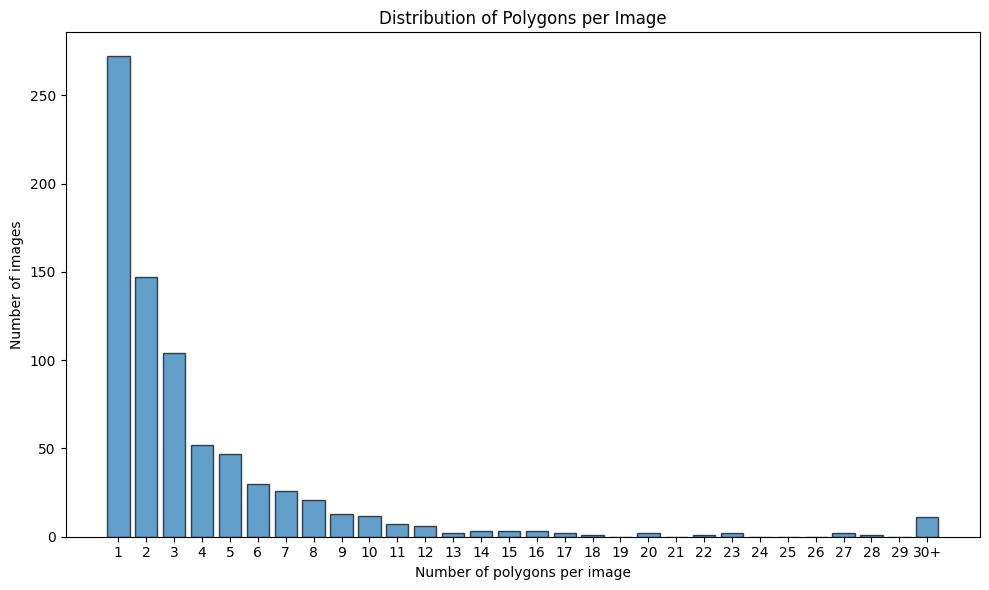

Images with polygons: 770
Mean polygons per image: 4.10
Median polygons per image: 2


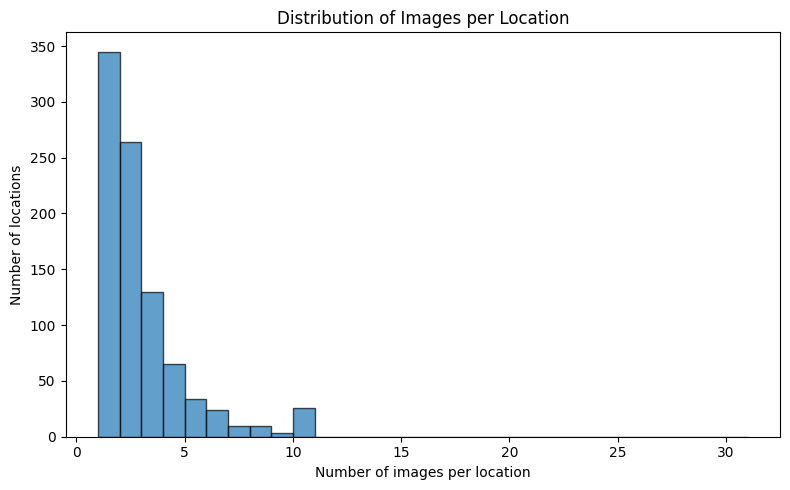

In [52]:
# Distribution of polygons per image (simple histogram)
polygons_per_image_count = polygons_df.groupby('image_id').size()

max_poly = min(int(polygons_per_image_count.max()), 30)
bins = range(1, max_poly + 2)

fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram counts
hist_counts = []
for i in range(len(bins) - 1):
    bin_start, bin_end = bins[i], bins[i + 1]
    if i == len(bins) - 2:  # Last bin includes everything >= bin_start
        count = (polygons_per_image_count >= bin_start).sum()
    else:
        count = ((polygons_per_image_count >= bin_start) & (polygons_per_image_count < bin_end)).sum()
    hist_counts.append(count)

ax.bar(np.arange(len(bins) - 1) + 0.5, hist_counts, width=0.8, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of polygons per image')
ax.set_ylabel('Number of images')
ax.set_title('Distribution of Polygons per Image')
ax.set_xticks(np.arange(len(bins) - 1) + 0.5)
xlabels = [str(b) for b in bins[:-1]]
xlabels[-1] = f'{bins[-2]}+'
ax.set_xticklabels(xlabels)
plt.tight_layout()
plt.show()

print(f"Images with polygons: {len(polygons_per_image_count)}")
print(f"Mean polygons per image: {polygons_per_image_count.mean():.2f}")
print(f"Median polygons per image: {polygons_per_image_count.median():.0f}")

# Also show the histogram of locations (not images) per bin
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(total_per_location, bins=bins, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of images per location')
ax.set_ylabel('Number of locations')
ax.set_title('Distribution of Images per Location')
plt.tight_layout()
plt.show()

### Distribution of Polygon Sizes by Category

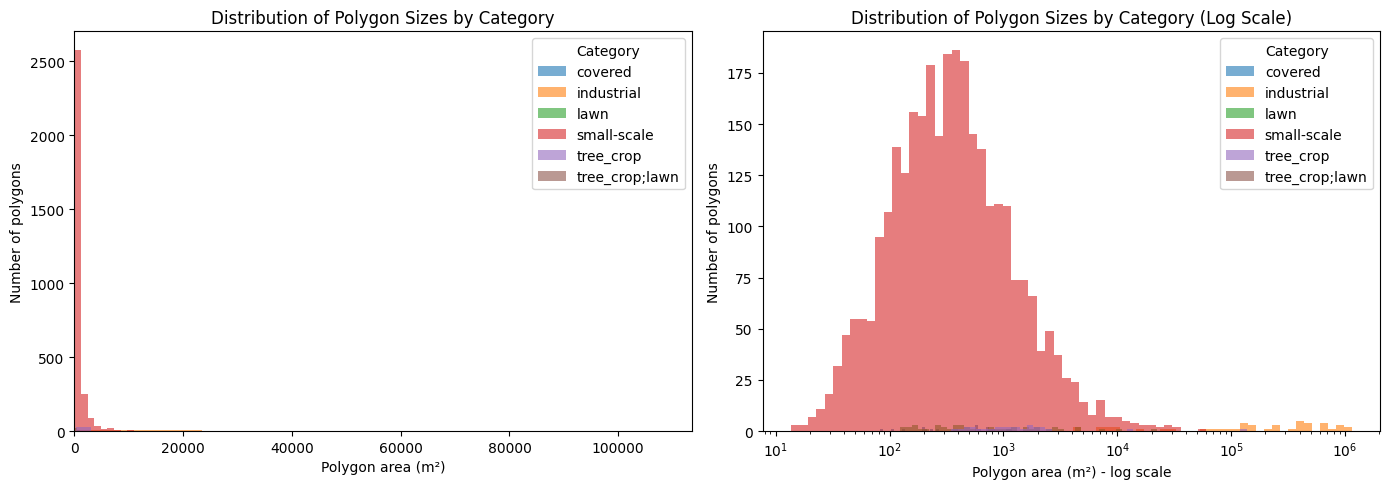

Polygon size statistics by category (m²):
                 count       mean        std     min       25%        50%  \
category                                                                    
covered           21.0     472.86     329.80   73.15    200.15     394.70   
industrial        48.0  319505.21  324208.06  422.15  53546.15  186869.50   
lawn              46.0    1848.07    3726.73   68.45    270.87     490.85   
small-scale     3014.0     846.44    2278.65   13.51    150.23     334.07   
tree_crop         29.0    6243.90   25272.57  268.96    650.43    1125.33   
tree_crop;lawn     1.0     570.29        NaN  570.29    570.29     570.29   

                      75%         max  
category                               
covered            714.25     1182.97  
industrial      505562.12  1150786.99  
lawn              1709.99    22422.43  
small-scale        745.28    60685.02  
tree_crop         1675.49   137122.25  
tree_crop;lawn     570.29      570.29  


In [57]:
# Distribution of polygon sizes by category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw histogram
ax = axes[0]
categories = sorted(polygons_df['category'].unique())
for cat in categories:
    cat_data = polygons_df[polygons_df['category'] == cat]['polygon_area_m2']
    ax.hist(cat_data, bins=50, alpha=0.6, label=cat)
ax.set_xlabel('Polygon area (m²)')
ax.set_ylabel('Number of polygons')
ax.set_title('Distribution of Polygon Sizes by Category')
ax.legend(title='Category')
ax.set_xlim(0, polygons_df['polygon_area_m2'].quantile(0.99))  # Clip at 99th percentile

# Right: log scale
ax = axes[1]
for cat in categories:
    cat_data = polygons_df[polygons_df['category'] == cat]['polygon_area_m2']
    # Add small epsilon to avoid log(0)
    ax.hist(cat_data, bins=np.logspace(np.log10(cat_data.min() + 0.01), 
                                        np.log10(cat_data.max() + 0.01), 50), 
            alpha=0.6, label=cat)
ax.set_xscale('log')
ax.set_xlabel('Polygon area (m²) - log scale')
ax.set_ylabel('Number of polygons')
ax.set_title('Distribution of Polygon Sizes by Category (Log Scale)')
ax.legend(title='Category')

plt.tight_layout()
plt.show()

# Summary statistics

print("Polygon size statistics by category (m²):")
print(polygons_df.groupby('category')['polygon_area_m2'].describe().round(2))

## Splits